<a href="https://colab.research.google.com/github/Dexter0013/Vision-Transformer/blob/main/VideoMAE/Quick_inference_with_VideoMAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set-up environment

First, let's install 🤗 Transformers and decord, which we'll use to decode a video.

In [17]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [18]:
!pip install -q decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 51.9 MB/s eta 0:00:00


## Load video

Let's load a video from the [Kinetics-400](https://www.deepmind.com/open-source/kinetics) dataset. This dataset contains millions of YouTube videos annotated with one out of 400 possible classes.



In [19]:
!wget https://huggingface.co/datasets/nielsr/video-demo/resolve/main/eating_spaghetti.mp4

--2026-07-05 23:05:01--  https://huggingface.co/datasets/nielsr/video-demo/resolve/main/eating_spaghetti.mp4
Resolving huggingface.co (huggingface.co)... 3.165.160.59, 3.165.160.12, 3.165.160.61, ...
Connecting to huggingface.co (huggingface.co)|3.165.160.59|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/628b3dfc8fb67b90658549a6/72faa2d69b0b7de629f7be7e6e96e9df7b8c547eae03f197280e0d43e61adba7?X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27eating_spaghetti.mp4%3B+filename%3D%22eating_spaghetti.mp4%22%3B&response-content-type=video%2Fmp4&user_id=public&Expires=1783296301&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjI4YjNkZmM4ZmI2N2I5MDY1ODU0OWE2LzcyZmFhMmQ2OWIwYjdkZTYyOWY3YmU3ZTZlOTZlOWRmN2I4YzU0N2VhZTAzZjE5NzI4MGUwZDQzZTYxYWRiYTdcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPWlubGluZSUzQitmaWxlbmFtZSUyQSUzRF

In [ ]:
from ipywidgets import Video

video_path = "eating_spaghetti.mp4"
Video.from_file(video_path, width=500)

Video(value=b'\x00\x00\x00 ftypisom\x00\x00\x02\x00isomiso2avc1mp41\x00\x00\x00\x08free\x00\x0fI\xb7mdat\x00\x…

## Prepare video for model

We can prepare the video for the model using VideoMAEFeatureExtractor. We'll first sample 16 frames (out of the possible 300), and provide this to the feature extractor.

It will perform some basic preprocessing, namely resize, center crop and normalize each frame of the video.

In [23]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

config.json:   0%|          | 0.00/22.9k [00:00<?, ?B/s]

In [25]:
from decord import VideoReader, cpu
import numpy as np

# video clip consists of 300 frames (10 seconds at 30 FPS)
vr = VideoReader(video_path, num_threads=1, ctx=cpu(0))

def sample_frame_indices(clip_len, frame_sample_rate, seg_len):
  converted_len = int(clip_len * frame_sample_rate)
  end_idx = np.random.randint(converted_len, seg_len)
  str_idx = end_idx - converted_len
  index = np.linspace(str_idx, end_idx, num=clip_len)
  index = np.clip(index, str_idx, end_idx - 1).astype(np.int64)

  return index

vr.seek(0)
index = sample_frame_indices(clip_len=16, frame_sample_rate=4, seg_len=len(vr))
buffer = vr.get_batch(index).asnumpy()
buffer.shape

(16, 360, 640, 3)

In [26]:
# create a list of NumPy arrays
video = [buffer[i] for i in range(buffer.shape[0])]

encoding = processor(video, return_tensors="pt")
print(encoding.pixel_values.shape)

torch.Size([1, 16, 3, 224, 224])


## Load model

Next, let's load the model and move it to the GPU, if it's available.

In [28]:
from transformers import VideoMAEForVideoClassification
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-large-finetuned-kinetics")
model.to(device)

config.json:   0%|          | 0.00/22.9k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/318 [00:00<?, ?it/s]

[transformers] VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-large-finetuned-kinetics
Key                                                            | Status     | 
---------------------------------------------------------------+------------+-
videomae.encoder.layer.{0...23}.attention.attention.v_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...23}.attention.attention.q_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...23}.attention.attention.query.bias | MISSING    | 
videomae.encoder.layer.{0...23}.attention.attention.key.bias   | MISSING    | 
videomae.encoder.layer.{0...23}.attention.attention.value.bias | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0-23): 24 x VideoMAELayer(
          (attention): VideoMAEAttention(
            (attention): VideoMAESelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
            )
            (output): VideoMAESelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): VideoMAEIntermediate(
            (dense): Linear(in_features=1024, out_features=4096, bias=Tru

## Forward pass

In [29]:
pixel_values = encoding.pixel_values.to(device)

# forward pass
with torch.no_grad():
  outputs = model(pixel_values)
  logits = outputs.logits

In [30]:
predicted_class_idx = logits.argmax(-1).item()

print("Predicted class:", model.config.id2label[predicted_class_idx])

Predicted class: eating spaghetti


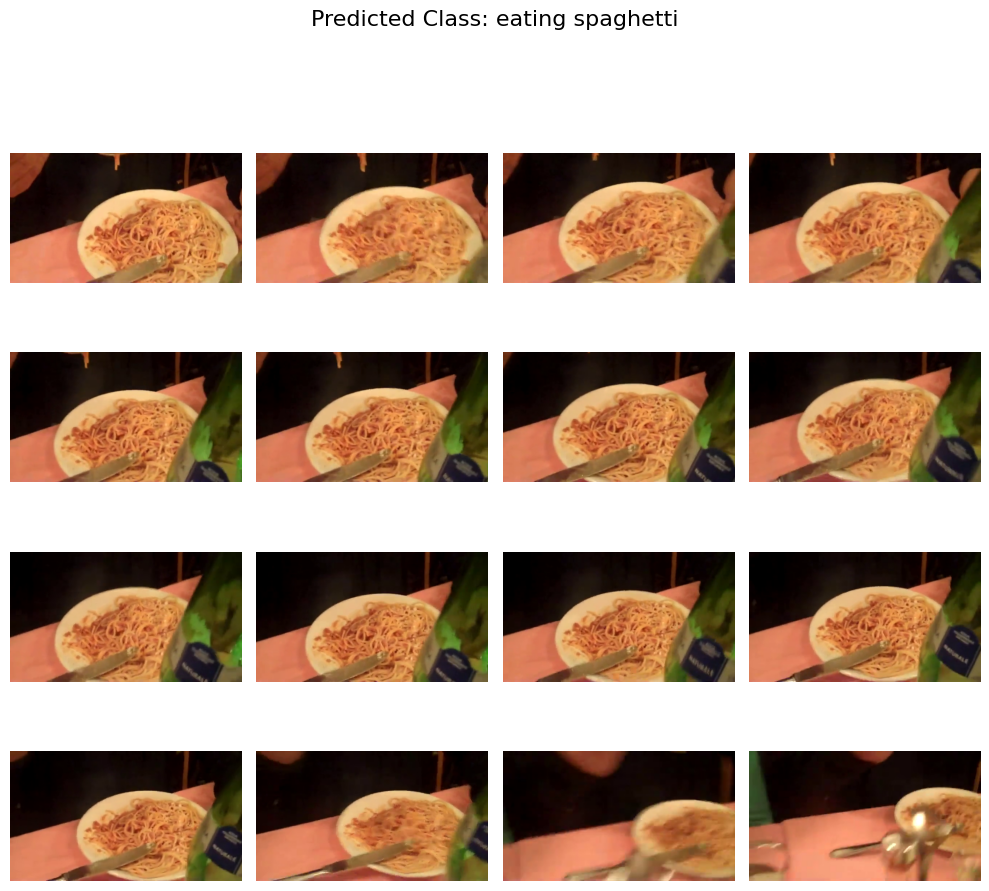

In [31]:
import matplotlib.pyplot as plt

predicted_label = model.config.id2label[predicted_class_idx]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle(f"Predicted Class: {predicted_label}", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(video):
        ax.imshow(video[i])
        ax.axis('off')
    else:
        ax.remove()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()